In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
from modules import CHIP
# 初始化操作
chip=CHIP(local_ip="192.168.1.15",remote_ip="192.168.1.10",remote_port=7,debug=1)               # 连接硬件平台
chip.set_device_cfg(deviceType=0,IsNew32=True)                                          # 配置器件设置：0表示ReRAM，1表示ECRAM
chip.adc.set_sample_times(adc_sample_times=32)                                          # 设置ADC采样次数
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=400,adc_last_gap=100)                     # ADC采样时序配置


chip.adc.set_sample_times(adc_sample_times=16)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=1000,adc_last_gap=40)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(100, 100,delay3=100)
# chip.add_compiler("./compiler/code/")
# chip.compensation.initop("../chip_data/chip6_/pcb_203/")

chip.set_cim_reset(flag1=False,flag2=0b0000_0000,flag3="",reset_ans=1)

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 37851
完整字节码: 55aa010900000fff
完整字节码: 55aa010100000080
完整字节码: 55aa010100000100
完整字节码: 55aa010d00000001
完整字节码: 55aa010e00000001
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: flt           	字节码: 09 00 00 0f ff
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 00 80
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 01 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: cim_ss        	字节码: 0d 00 00 00 01
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: ser_para_sel  	字节码: 0e 00 00 00 01

完整字节码: 55aa010b00000001
模式: 1
	帧头:          	字节码: 55 aa 01
	指令: cim_reset	字节码: 0b 00 00 00 01

完整字节码: 55aa01030000a200
完整字节码: 55aa01040000a200
完整字节码: 55aa01050000a200
完整字节码: 55aa01060000a200
完整字节码: 55aa01320000a200
完整字节码: 55aa01330000a200
完整字节码: 55aa01340000a200
完整字节码: 55aa01350000a200
完整字节码: 55aa0101000f001e
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: adc0_in       	字节码: 03 00 00 a2 00
模式: 1
	帧头:         

In [14]:
selected_devices = np.ones((256,256),dtype=bool)                                        # 配置需要读取的器件，True表示被选中，False表示未选中
# 执行读操作，返回三个数据矩阵，ADC电压(V)、电导(μS)、电阻(kΩ)
voltage, conductance, resistance = chip.read4(crossbar=selected_devices,read_voltage=0.1,tg=5,gain=1,from_row=True,sub_base=True,
                                             split_type=1, row_type=0, col_type=0)
# 展示阵列器件的电导值


完整字节码: 55aa011000000001
模式: 1
	帧头:     	字节码: 55 aa 01
	指令: gain	字节码: 10 00 00 00 01

完整字节码: 55aa040000000d03000000030100000302000003030000030400000305000003060000030700000308000003090000030a0000030b00000b000000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 0d
	指令: pl_dac_v      	字节码: 03 00 00 00
	指令: pl_dac_v      	字节码: 03 01 00 00
	指令: pl_dac_v      	字节码: 03 02 00 00
	指令: pl_dac_v      	字节码: 03 03 00 00
	指令: pl_dac_v      	字节码: 03 04 00 00
	指令: pl_dac_v      	字节码: 03 05 00 00
	指令: pl_dac_v      	字节码: 03 06 00 00
	指令: pl_dac_v      	字节码: 03 07 00 00
	指令: pl_dac_v      	字节码: 03 08 00 00
	指令: pl_dac_v      	字节码: 03 09 00 00
	指令: pl_dac_v      	字节码: 03 0a 00 00
	指令: pl_dac_v      	字节码: 03 0b 00 00
	指令: pl_exit       	字节码: 0b 00 00 00

完整字节码: 55aa010100008000
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

完整字节码: 55aa0400000004190100001a0000001b0100000b000000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: p

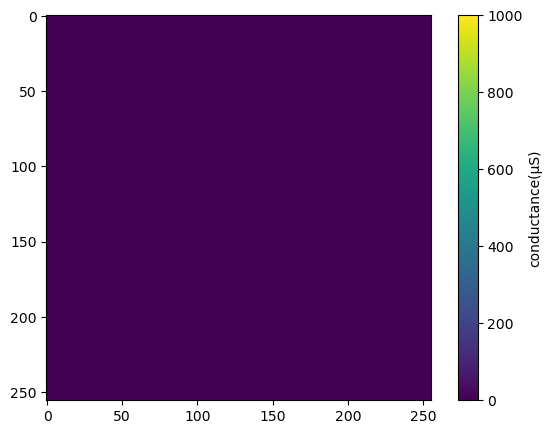

In [15]:
plt.figure(figsize=(7,5))
im = plt.imshow(conductance,norm=Normalize(vmin=0, vmax=1000))
cbar = plt.colorbar(im)
cbar.set_label("conductance(μS)")
plt.show()

In [ ]:
selected_devices = np.ones((256,256),dtype=bool)                                        # 配置需要读取的器件，True表示被选中，False表示未选中
tg = np.ones((256,256))                                                                 # 配置每个器件的栅极电压参数，每个器件栅极电压可以不一致
# 对选中器件执行SET操作
chip.write4(crossbar=selected_devices,write_voltage=1,tg=tg,pulse_width=1e-6,set_device=True,
            split_type=0, row_type=0, col_type=0)